In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [3]:
df = pd.read_csv("project_2.csv")

In [4]:
df

,Date,Open,High,Low,Close,Volume,OpenInt
0,1986-03-13,0.06720,0.07533,0.06720,0.07533,1371330506,0
1,1986-03-14,0.07533,0.07533,0.07533,0.07533,409569463,0
2,1986-03-17,0.07533,0.07533,0.07533,0.07533,176995245,0
3,1986-03-18,0.07533,0.07533,0.07533,0.07533,90067008,0
4,1986-03-19,0.07533,0.07533,0.07533,0.07533,63655515,0
...,...,...,...,...,...,...,...
7978,2017-11-06,84.20000,84.70000,84.08250,84.47000,19852151,0
7979,2017-11-07,84.77000,84.90000,83.93000,84.26000,17927878,0
7980,2017-11-08,84.14000,84.61000,83.83000,84.56000,18029584,0
7981,2017-11-09,84.11000,84.27000,82.90000,84.09000,21175384,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7983 entries, 0 to 7982
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     7983 non-null   object 
 1   Open     7983 non-null   float64
 2   High     7983 non-null   float64
 3   Low      7983 non-null   float64
 4   Close    7983 non-null   float64
 5   Volume   7983 non-null   int64  
 6   OpenInt  7983 non-null   int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 436.7+ KB


In [6]:
df.isnull()

,Date,Open,High,Low,Close,Volume,OpenInt
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
7978,False,False,False,False,False,False,False
7979,False,False,False,False,False,False,False
7980,False,False,False,False,False,False,False
7981,False,False,False,False,False,False,False


In [7]:
df.isnull().sum

<bound method DataFrame.sum of        Date   Open   High    Low  Close  Volume  OpenInt
0     False  False  False  False  False   False    False
1     False  False  False  False  False   False    False
2     False  False  False  False  False   False    False
3     False  False  False  False  False   False    False
4     False  False  False  False  False   False    False
...     ...    ...    ...    ...    ...     ...      ...
7978  False  False  False  False  False   False    False
7979  False  False  False  False  False   False    False
7980  False  False  False  False  False   False    False
7981  False  False  False  False  False   False    False
7982  False  False  False  False  False   False    False

[7983 rows x 7 columns]>

In [10]:
df.describe()

,Open,High,Low,Close,Volume,OpenInt
count,7983.000000,7983.000000,7983.000000,7983.000000,7.983000e+03,7983.0
mean,18.977859,19.187219,18.773635,18.984698,7.945800e+07,0.0
std,16.416068,16.552604,16.277882,16.424012,5.214889e+07,0.0
min,0.067200,0.067200,0.067200,0.067200,0.000000e+00,0.0
25%,2.113300,2.155100,2.079700,2.113300,4.910587e+07,0.0
50%,20.462000,20.697000,20.251000,20.469000,7.059385e+07,0.0
75%,25.475000,25.754000,25.233000,25.483500,9.734927e+07,0.0
max,84.770000,86.200000,84.082500,84.560000,1.371331e+09,0.0


In [11]:
df.drop_duplicates(inplace=True)

In [13]:
df['Date'] = pd.to_datetime(df['Date'])

In [14]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'OpenInt'], dtype='object')

In [15]:
df.duplicated().sum()

0

In [16]:
df.set_index('Date', inplace=True)

## Exploratory Data Analysis (EDA)

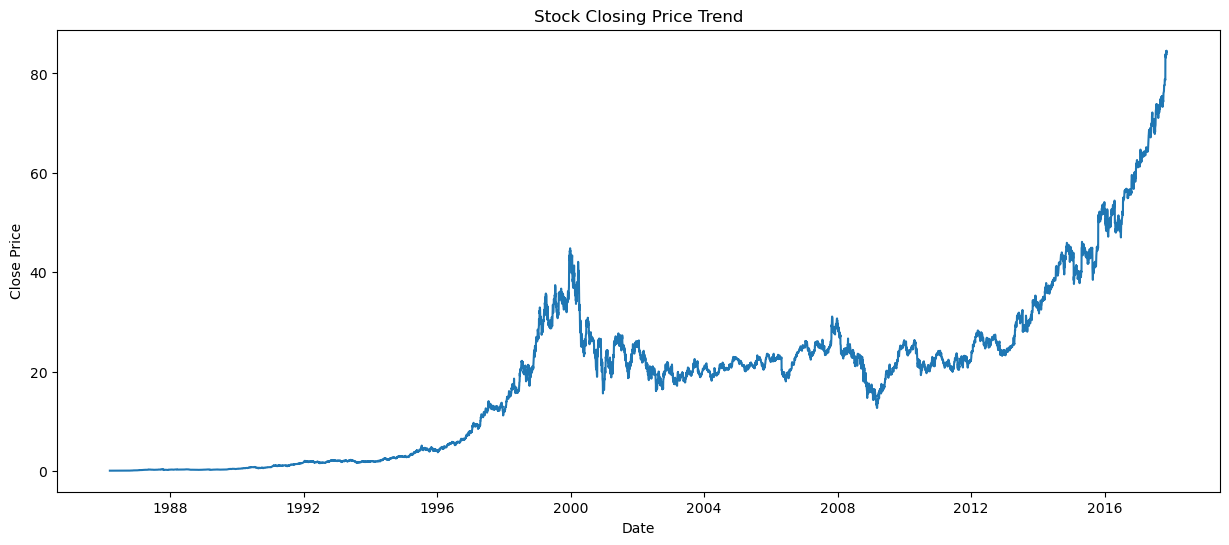

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(df.index, df['Close'])

plt.title("Stock Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.show()

## Volume Trend

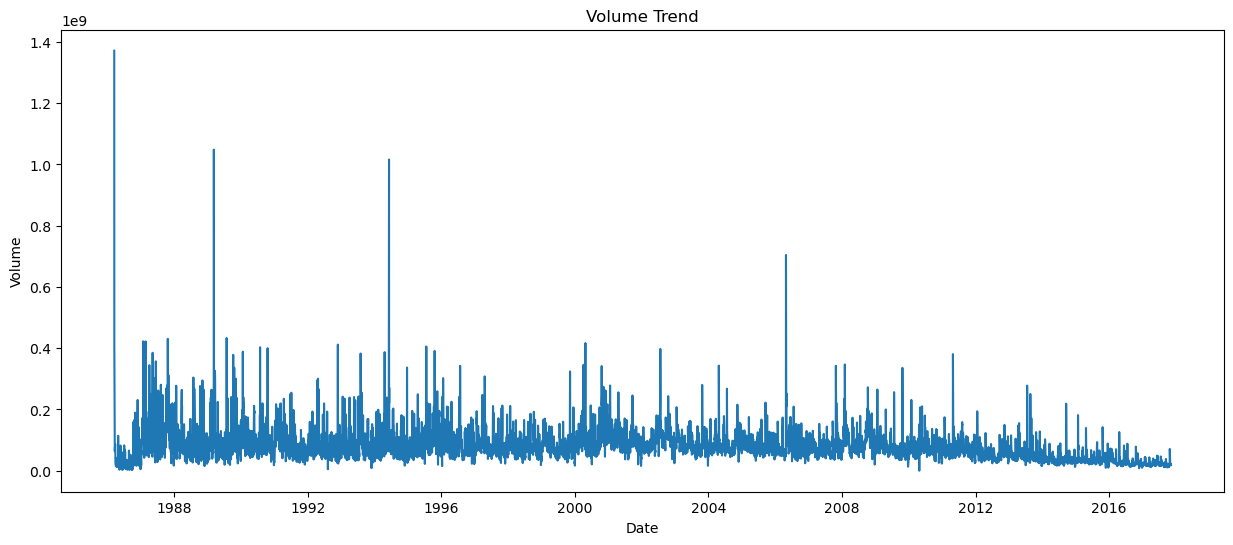

In [19]:
plt.figure(figsize=(15,6))

plt.plot(df.index, df['Volume'])

plt.title("Volume Trend")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.show()

## 10-Day Moving Average

In [22]:
df['MA10'] = df['Close'].rolling(window=10).mean()

In [23]:
df['MA10']

Date
1986-03-13       NaN
1986-03-14       NaN
1986-03-17       NaN
1986-03-18       NaN
1986-03-19       NaN
               ...  
2017-11-06    82.297
2017-11-07    82.837
2017-11-08    83.430
2017-11-09    83.963
2017-11-10    83.969
Name: MA10, Length: 7983, dtype: float64

In [24]:
df['MA10'].min

<bound method Series.min of Date
1986-03-13       NaN
1986-03-14       NaN
1986-03-17       NaN
1986-03-18       NaN
1986-03-19       NaN
               ...  
2017-11-06    82.297
2017-11-07    82.837
2017-11-08    83.430
2017-11-09    83.963
2017-11-10    83.969
Name: MA10, Length: 7983, dtype: float64>

In [25]:
df['MA10'].rolling(window=10)

Rolling [window=10,center=False,axis=0,method=single]

## 50-Day Moving Average

In [26]:
df['MA50'] = df['Close'].rolling(window=50).mean()

In [27]:
df['MA50']

Date
1986-03-13        NaN
1986-03-14        NaN
1986-03-17        NaN
1986-03-18        NaN
1986-03-19        NaN
               ...   
2017-11-06    76.6418
2017-11-07    76.8704
2017-11-08    77.1006
2017-11-09    77.3022
2017-11-10    77.4836
Name: MA50, Length: 7983, dtype: float64

In [28]:
df['MA50'].isnull().sum

<bound method Series.sum of Date
1986-03-13     True
1986-03-14     True
1986-03-17     True
1986-03-18     True
1986-03-19     True
              ...  
2017-11-06    False
2017-11-07    False
2017-11-08    False
2017-11-09    False
2017-11-10    False
Name: MA50, Length: 7983, dtype: bool>

In [29]:
df['MA50'].dropna(inplace=True)

In [30]:
df['MA50']

Date
1986-03-13        NaN
1986-03-14        NaN
1986-03-17        NaN
1986-03-18        NaN
1986-03-19        NaN
               ...   
2017-11-06    76.6418
2017-11-07    76.8704
2017-11-08    77.1006
2017-11-09    77.3022
2017-11-10    77.4836
Name: MA50, Length: 7983, dtype: float64

In [31]:
df.dropna(inplace=True)

In [32]:
df

,Open,High,Low,Close,Volume,OpenInt,MA10,MA50
Date,,,,,,,,
1986-05-22,0.08389,0.08389,0.08389,0.08389,5856460,0,0.083890,0.078283
1986-05-23,0.08389,0.08389,0.08389,0.08389,5435406,0,0.083890,0.078454
1986-05-27,0.08389,0.08389,0.08389,0.08389,18449763,0,0.083890,0.078625
1986-05-28,0.08389,0.08389,0.08389,0.08389,20631587,0,0.083890,0.078796
1986-05-29,0.08389,0.09222,0.08389,0.09222,60708149,0,0.084723,0.079134
...,...,...,...,...,...,...,...,...
2017-11-06,84.20000,84.70000,84.08250,84.47000,19852151,0,82.297000,76.641800
2017-11-07,84.77000,84.90000,83.93000,84.26000,17927878,0,82.837000,76.870400
2017-11-08,84.14000,84.61000,83.83000,84.56000,18029584,0,83.430000,77.100600


In [33]:
df['MA10'] = df['Close'].rolling(window=10).mean()

df['MA50'] = df['Close'].rolling(window=50).mean()

## Daily Return Calculate 

In [34]:
df['Daily_Return'] = df['Close'].pct_change()

In [35]:
df['Daily_Return']

Date
1986-05-22         NaN
1986-05-23    0.000000
1986-05-27    0.000000
1986-05-28    0.000000
1986-05-29    0.099297
                ...   
2017-11-06    0.003922
2017-11-07   -0.002486
2017-11-08    0.003560
2017-11-09   -0.005558
2017-11-10   -0.002616
Name: Daily_Return, Length: 7934, dtype: float64

In [36]:
df[['Close','Daily_Return']].head()

,Close,Daily_Return
Date,,
1986-05-22,0.08389,NaN
1986-05-23,0.08389,0.000000
1986-05-27,0.08389,0.000000
1986-05-28,0.08389,0.000000
1986-05-29,0.09222,0.099297


## Daily Return ka Graph

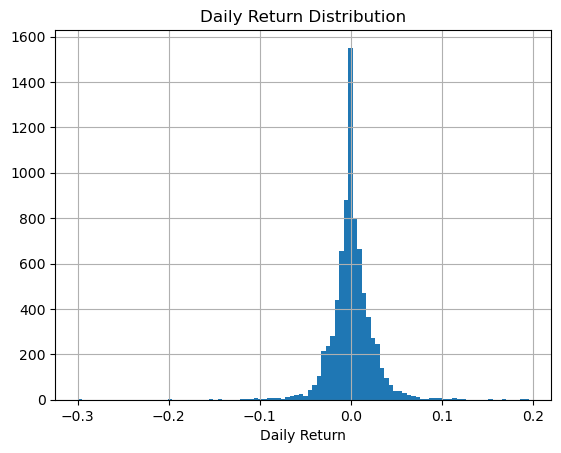

In [38]:
df['Daily_Return'].hist(bins=100)

plt.title("Daily Return Distribution")

plt.xlabel("Daily Return")

plt.show()

## Target Variable

In [39]:
import numpy as np

df['Target'] = np.where(
    df['Close'].shift(-1) > df['Close'],
    1,
    0
)

In [41]:
df['Target'] 

Date
1986-05-22    0
1986-05-23    0
1986-05-27    0
1986-05-28    1
1986-05-29    0
             ..
2017-11-06    0
2017-11-07    1
2017-11-08    0
2017-11-09    0
2017-11-10    0
Name: Target, Length: 7934, dtype: int32

In [42]:
df[['Close','Target']].tail()

,Close,Target
Date,,
2017-11-06,84.47,0
2017-11-07,84.26,1
2017-11-08,84.56,0
2017-11-09,84.09,0
2017-11-10,83.87,0


## NaN Values Remove

In [43]:
df.dropna(inplace=True)

## Features Select

In [44]:
X = df[['Open',
        'High',
        'Low',
        'Close',
        'Volume',
        'MA10',
        'MA50']]

y = df['Target']

In [45]:
print(X.shape)
print(y.shape)

(7885, 7)
(7885,)


## Train-Test Split

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [50]:
print(X_train.shape)
print(X_test.shape)

(6308, 7)
(1577, 7)


## Model Training (Logistic Regression)

In [51]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

## Prediction

In [52]:
y_pred = model.predict(X_test)

In [53]:
print(y_pred[:10])

[0 0 0 0 0 0 1 0 0 0]


In [54]:
y_pred[:10]

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

## Accuracy

In [55]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.5110970196575777


## Confusion Matrix

In [56]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 62 715]
 [ 56 744]]


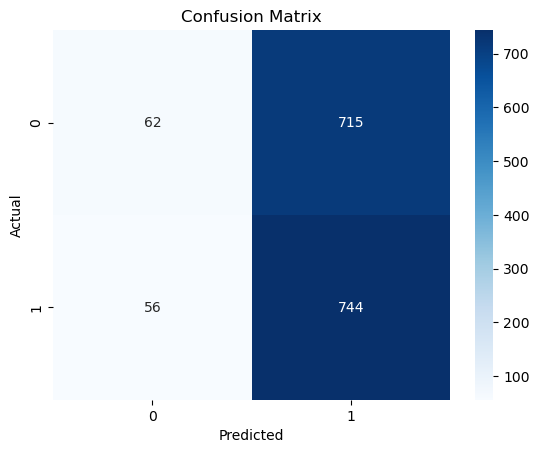

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Classification Report

In [58]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.53      0.08      0.14       777
           1       0.51      0.93      0.66       800

    accuracy                           0.51      1577
   macro avg       0.52      0.50      0.40      1577
weighted avg       0.52      0.51      0.40      1577



## Actual vs Predicted Visualization

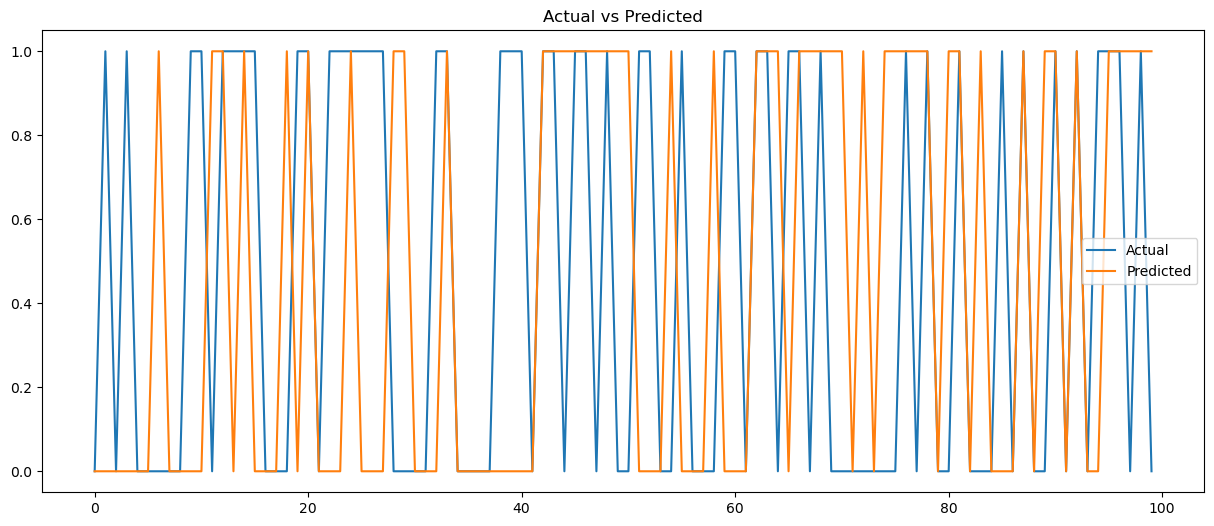

In [59]:
plt.figure(figsize=(15,6))

plt.plot(y_test.values[:100],
         label='Actual')

plt.plot(y_pred[:100],
         label='Predicted')

plt.title("Actual vs Predicted")

plt.legend()

plt.show()

## Feature Importance (Optional for Logistic Regression)

In [60]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

print(importance)

  Feature   Coefficient
0    Open  9.894650e-04
1    High  1.006624e-03
2     Low  9.706096e-04
3   Close  9.645658e-04
4  Volume -2.088410e-09
5    MA10  9.802368e-04
6    MA50  9.982403e-04


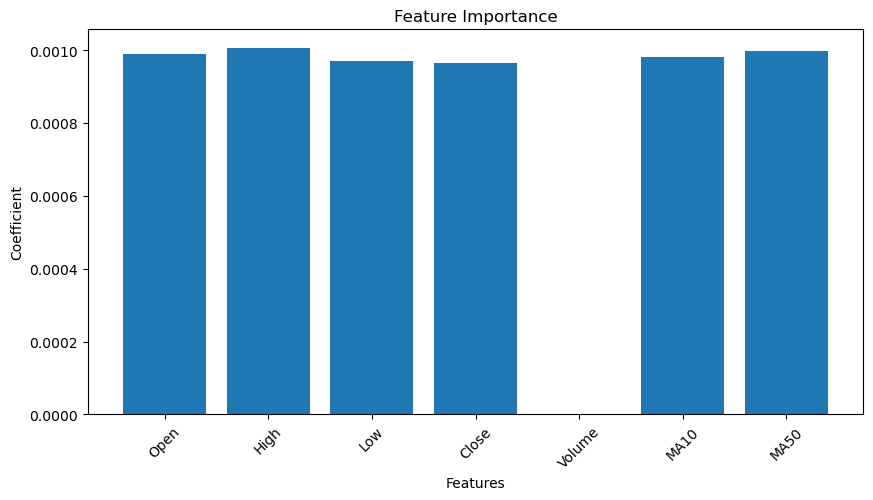

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(importance['Feature'],
        importance['Coefficient'])

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.xlabel("Features")
plt.ylabel("Coefficient")

plt.show()

## Add the Random Forest Model 

In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.501585288522511


## Add The XGBoost Model 

In [64]:
pip install xgboost


  Using cached xgboost-3.3.0-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.3.0-py3-none-win_amd64.whl (69.5 MB)


In [65]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.48573240329740014


## compare with Logistic Regression vs Random Forest vs XGBoost 

In [66]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression',
              'Random Forest',
              'XGBoost'],

    'Accuracy': [accuracy,
                 rf_accuracy,
                 xgb_accuracy]
})

print(comparison)

                 Model  Accuracy
0  Logistic Regression  0.511097
1        Random Forest  0.501585
2              XGBoost  0.485732


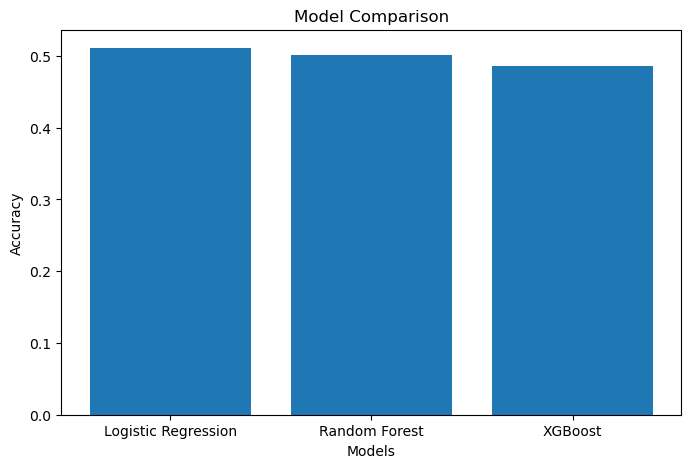

In [67]:


plt.figure(figsize=(8,5))

plt.bar(comparison['Model'],
        comparison['Accuracy'])

plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

## Add Candlestick Chart

In [68]:
pip install mplfinance

  Using cached mplfinance-0.12.10b0-py3-none-any.whl.metadata (19 kB)
Using cached mplfinance-0.12.10b0-py3-none-any.whl (75 kB)
Note: you may need to restart the kernel to use updated packages.


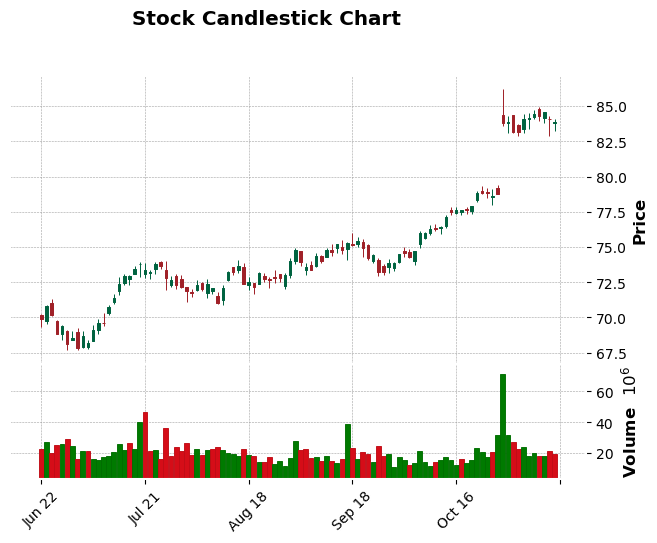

In [69]:
import mplfinance as mpf

df_candle = df.copy()

df_candle.index = pd.to_datetime(df_candle.index)

mpf.plot(
    df_candle.tail(100),
    type='candle',
    style='charles',
    title='Stock Candlestick Chart',
    volume=True
)

## Real-Time Yahoo Finance Data Integration

In [70]:
pip install yfinance

  Using cached yfinance-1.4.1-py2.py3-none-any.whl.metadata (6.2 kB)
  Using cached multitasking-0.0.13-py3-none-any.whl.metadata (16 kB)
  Using cached peewee-4.1.0-py3-none-any.whl.metadata (10 kB)
  Using cached curl_cffi-0.15.0-cp310-abi3-win_amd64.whl.metadata (18 kB)
Using cached yfinance-1.4.1-py2.py3-none-any.whl (137 kB)
Using cached curl_cffi-0.15.0-cp310-abi3-win_amd64.whl (1.7 MB)
Using cached multitasking-0.0.13-py3-none-any.whl (16 kB)
Using cached peewee-4.1.0-py3-none-any.whl (155 kB)
   ---------------------------------------- 0.0/178.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/178.7 kB ? eta -:--:--
   -- ------------------------------------- 10.2/178.7 kB ? eta -:--:--
   -- ------------------------------------- 10.2/178.7 kB ? eta -:--:--
   ---- ---------------------------------- 20.5/178.7 kB 162.5 kB/s eta 0:00:01
   -------- ------------------------------ 41.0/178.7 kB 245.8 kB/s eta 0:00:01
   --------------------- ---------------- 102.4/

In [71]:
import yfinance as yf

live_data = yf.download(
    "AAPL",
    start="2025-01-01",
    end="2026-01-01"
)

print(live_data.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2025-01-02  242.301910  247.518580  240.284799  247.349646  55740700
2025-01-03  241.815018  242.629804  240.354349  241.815018  40244100
2025-01-06  243.444626  245.759836  241.656050  242.759004  45045600
2025-01-07  240.672318  243.991110  239.817777  241.437418  40856000
2025-01-08  241.159195  242.162793  238.526025  240.384148  37628900


In [72]:
stocks = ["AAPL", "MSFT", "TSLA"]

for stock in stocks:

    data = yf.download(
        stock,
        start="2024-01-01",
        end="2026-01-01"
    )

    print("\n", stock)
    print(data.head())

[*********************100%***********************]  1 of 1 completed



 AAPL
Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2024-01-02  183.562195  186.330858  181.831782  185.055288  82488700
2024-01-03  182.187775  183.799536  181.376945  182.158112  58414500
2024-01-04  179.873917  181.040702  178.855446  180.111221  71983600
2024-01-05  179.152100  180.714417  178.153410  179.953046  62379700
2024-01-08  183.483078  183.522639  179.468523  180.051916  59144500


[*********************100%***********************]  1 of 1 completed



 MSFT
Price            Close        High         Low        Open    Volume
Ticker            MSFT        MSFT        MSFT        MSFT      MSFT
Date                                                                
2024-01-02  363.801483  368.735614  359.779620  366.734486  25258600
2024-01-03  363.536621  366.145927  361.486459  361.976929  23083500
2024-01-04  360.927338  365.988995  360.172024  363.605317  20901500
2024-01-05  360.740967  364.968819  359.514791  361.937716  21004600
2024-01-08  367.548767  368.049057  361.977030  362.261481  23134000


[*********************100%***********************]  1 of 1 completed


 TSLA
Price            Close        High         Low        Open     Volume
Ticker            TSLA        TSLA        TSLA        TSLA       TSLA
Date                                                                 
2024-01-02  248.419998  251.250000  244.410004  250.080002  104654200
2024-01-03  238.449997  245.679993  236.320007  244.979996  121082600
2024-01-04  237.929993  242.699997  237.729996  239.250000  102629300
2024-01-05  237.490005  240.119995  234.899994  236.860001   92488900
2024-01-08  240.449997  241.250000  235.300003  236.139999   85166600


## Final Model Selection

In [73]:
best_model = comparison.loc[
    comparison['Accuracy'].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model       Logistic Regression
Accuracy               0.511097
Name: 0, dtype: object
